# rs-embed Playground
<img src="https://raw.githubusercontent.com/cybergis/rs-embed/main/docs/assets/background.png" width="800" /> 

## Motivation
Remote sensing foundation models are powerful, but using them is often messy: different models expect different sensors, time windows, preprocessing, and output shapes.
`rs-embed` aim to let you use a single line of code to get embeddings from **any supported model** for **any place** and **any time**.

## What is embedding?
An embedding is a compact numeric representation produced by a pretrained model.
For remote sensing, you can think of it as a machine-readable description of a region of interest at a chosen time that can be reused for retrieval, clustering, classification, benchmarking, or spatial analysis.

## Why `rs-embed`
- Support embedding acquisition for any place and time, flexibly assist your downstream tasks
- Support from small-scale acquisition to large-scale export
- Supports simple usage, as well as highly customizable features
- Detailed documentation support


## What this notebook shows
1. set up the package and Google Earth Engine
2. define a reusable ROI and time window
3. inspect the provider patch visually
4. run one model, then vary preprocessing and output shape
5. scale to many ROIs and export a small dataset

<img src="https://raw.githubusercontent.com/cybergis/rs-embed/main/docs/assets/scale.png" width="550" /> 


Github: https://github.com/cybergis/rs-embed
Docs: https://cybergis.github.io/rs-embed/
Paper: https://arxiv.org/abs/2602.23678

> Recommended kernel: `rsembed`


Skip these if you already install the package

In [1]:
# !pip install rs-embed

## 0. Before You Run



In [2]:
import ee

ee.Authenticate()
ee.Initialize()

In [3]:
from plot_utils import (
    inspect_export_npz,
    plot_embedding_pseudocolor,
    show_input_chw,
    show_input_series,
    visualize_manifest_embeddings,
)

## 1. Define the request once
In `rs-embed`, most work starts by describing the ROI and time window, not by jumping straight to a model.
That separation is one of the package's main strengths: the same `spatial` and `temporal` specs can be reused for inspection, single-model inference, batching, and export.


In [4]:
from rs_embed import BBox, OutputSpec, PointBuffer, SensorSpec, TemporalSpec

# Spatial: point + buffer
spatial_point = PointBuffer(
    lon=121.5,  # , -122.407677
    lat=31.2,  # 37.787937
    buffer_m=2048,
)

# Spatial: bounding box
spatial_bbox = BBox(
    minlon=121.45,
    minlat=31.15,
    maxlon=121.65,
    maxlat=31.25,
)

# Temporal: single year
temporal_year = TemporalSpec.year(2021)

# Temporal: date range
temporal_range = TemporalSpec.range(
    "2022-06-01",
    "2022-09-01",
)

spatial_point, spatial_bbox, temporal_year, temporal_range

(PointBuffer(lon=121.5, lat=31.2, buffer_m=2048, crs='EPSG:4326'),
 BBox(minlon=121.45, minlat=31.15, maxlon=121.65, maxlat=31.25, crs='EPSG:4326'),
 TemporalSpec(mode='year', year=2021, start=None, end=None),
 TemporalSpec(mode='range', year=<function TemporalSpec.year at 0x14e09da46ca0>, start='2022-06-01', end='2022-09-01'))

## 2. Inspect the raw patch before the model


This is the debugging habit that saves the most time.
If the fetched Sentinel-2 patch already looks wrong, changing the embedding model will not fix it.
The cell below makes the input visible first; the later sections then scale from one ROI to many ROIs.


Sentinel-2 input quicklook               shape=(3, 410, 410) dtype=float32 min=0 max=2.14e+04


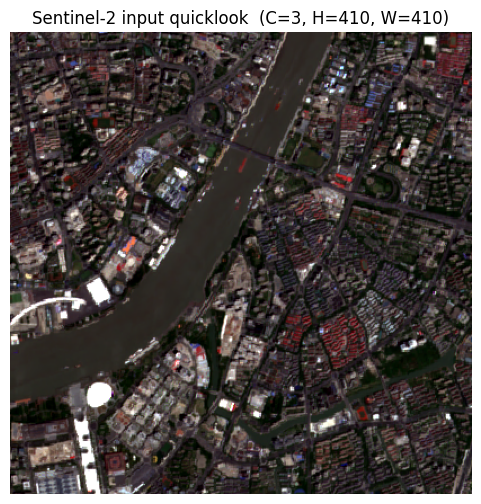

In [5]:
from rs_embed import inspect_provider_patch

check_out = inspect_provider_patch(
    spatial=spatial_point,
    temporal=temporal_range,
    sensor=SensorSpec(
        collection="COPERNICUS/S2_SR_HARMONIZED",
        bands=("B4", "B3", "B2"),
        scale_m=10,
        cloudy_pct=10,
    ),
    return_array=True,
)

show_input_chw(
    check_out["array_chw"],
    title="Sentinel-2 input quicklook",
    rgb_idx=(0, 1, 2),
)

## 3. One ROI, one model
This is the smallest complete inference loop: same ROI, one model call, one returned embedding.
Once this feels clear, the rest of the package is mostly about changing one axis at a time.


### 3.1 Minimal usage case

In practice, the core shape is:

`(model, spatial, temporal, output) -> Embedding`

Why this is useful:
- you keep the calling pattern stable while switching models
- the same request logic can move from exploration to production export
- output shape stays explicit instead of being hidden in model-specific wrappers



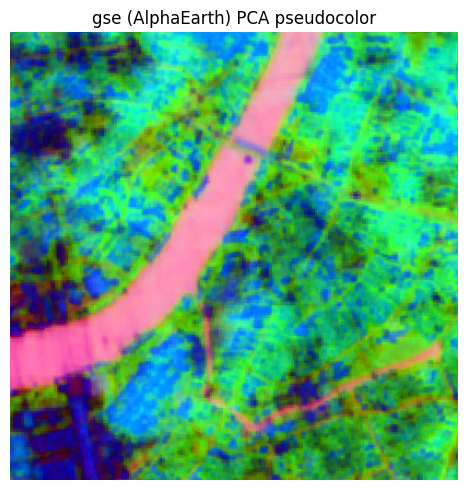

In [6]:
from rs_embed import get_embedding

emb = get_embedding(
    "gse",  # alphaearth global surface embedding
    spatial=spatial_point,
    temporal=temporal_year,
    output=OutputSpec.grid(),
)


# print("data.shape:", emb.data.shape)
# print("source:", emb.meta.get("source"))

pca = plot_embedding_pseudocolor(
    emb,
    title="gse (AlphaEarth) PCA pseudocolor",
)

### 3.2 Change preprocessing without changing the rest of the request
Different models impose different input-size constraints. `rs-embed` keeps that complexity in one place through `input_prep`.

- `resize`: fastest and the default option; good for quick comparison and large runs
- `tile`: preserves more spatial detail by splitting the ROI, but can get expensive quickly

<img src="https://raw.githubusercontent.com/cybergis/rs-embed/main/docs/assets/tile_playground.png" width="800" /> 

The point is not only that both modes exist. The point is that you can swap preprocessing while keeping the rest of the API unchanged.

For the full spec surface, see [API specs](https://cybergis.github.io/rs-embed/api_specs/).


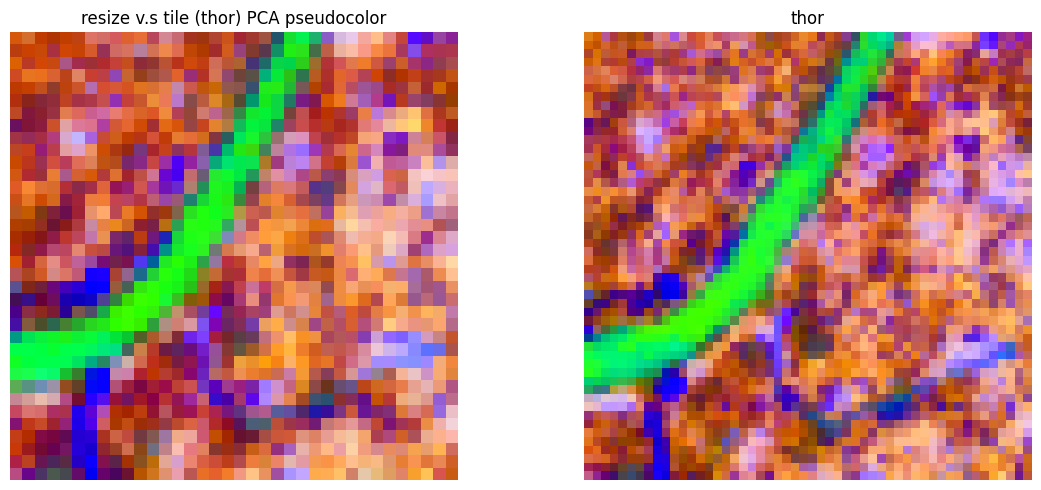

In [7]:
from rs_embed import get_embedding

# from rs_embed import InputPrepSpec
emb_resize = get_embedding(
    "thor",  #
    spatial=spatial_point,
    temporal=temporal_range,
    output=OutputSpec.grid(),
    input_prep="resize",
)

emb_tile = get_embedding(
    "thor",  #
    spatial=spatial_point,
    temporal=temporal_range,
    output=OutputSpec.grid(),
    input_prep="tile",
)

pca = plot_embedding_pseudocolor(
    emb=emb_resize,
    emb2=emb_tile,
    title="resize v.s tile (thor) PCA pseudocolor",
)

### 3.3 Time series models

Some models read a **stack of images over time**, not a single scene. `rs-embed` supports several of these multi-temporal models: `olmoearth`, `galileo`, `prithvi`, `anysat`, `agrifm`, through the *same* call you already know.

The model decides how many frames `T` to sample from it and how to space them, matched to its training cadence (monthly for `olmoearth`/`galileo`, ~28-day for `prithvi`, …). A sub-month window collapses to one composite (`T=1`); a multi-month window becomes a real time series. You don't change the request, only the result now summarizes change over time.

For the full per-model policy (frame counts, caps, out-of-distribution handling), see [Temporal Sampling](https://cybergis.github.io/rs-embed/temporal_sampling/).


/u/dingqi2/miniconda3/envs/rsembed_t/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
⚠ rs-embed UserWarning
│ OlmoEarth dropped 2 of 4 temporal bin(s) with no usable imagery (no scene passed the cloud filter): 2022-06-01→2022-07-01, 2022-08-30→2022-09-01. Encoded 2 frame(s) instead. To recover them, raise cloudy_pct, widen/shift the window, or pass temporal_mode='single' if a single composite is acceptable.
╰ rs_embed/embedders/onthefly_olmoearth.py:1147


temporal range : ('2022-06-01', '2022-09-01')
temporal mode  : multi
frames (T)     : 2
variant        : tiny_v1_1
embedding shape: (192, 104, 104)


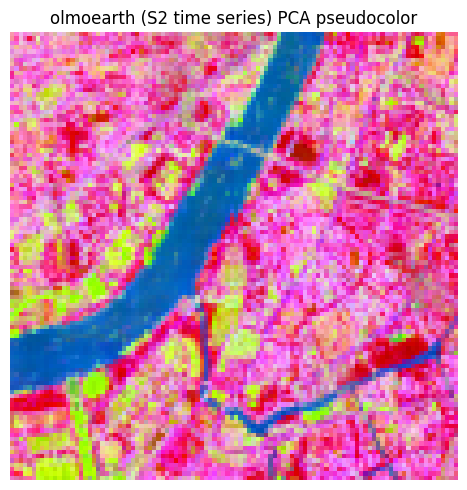

In [17]:
from rs_embed import get_embedding

# olmoearth reads a Sentinel-2 time series. The 3-month window auto-resolves to
# "multi": olmoearth slices it into 30-day bins (its monthly training cadence).
emb_time = get_embedding(
    "olmoearth",
    spatial=spatial_point,
    temporal=temporal_range,  # 2022-06-01 -> 2022-09-01
    output=OutputSpec.grid(),
)

# meta records how the window became a time series:
print("temporal range :", emb_time.meta["temporal_range"])
print("temporal mode  :", emb_time.meta["temporal_mode"])  # 'multi'
print("frames (T)     :", emb_time.meta["n_frames"])  # 30-day bins that had imagery
print("variant        :", emb_time.meta["variant"])
print("embedding shape:", emb_time.data.shape)  # (D, H', W')

pca = plot_embedding_pseudocolor(
    emb_time,
    title="olmoearth (S2 time series) PCA pseudocolor",
)

**Peek at the imagery behind the embedding.** The result above is one tensor, but it was built from a *sequence* of scenes. olmoearth slices the window into 30-day bins and fetches one Sentinel-2 composite per bin, dropping bins with no clear scene — which is why `n_frames` can be smaller than the number of bins. Reusing `inspect_provider_patch` from Section 2 per bin shows exactly that series.

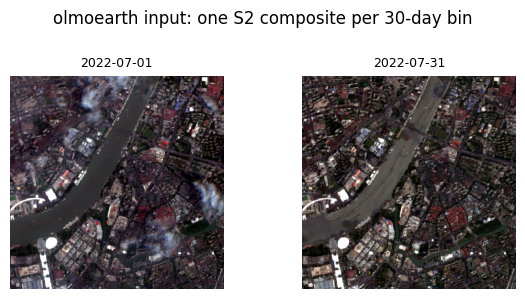

In [ ]:
# olmoearth slices the window into 30-day bins and fetches one S2 composite per
# bin. Reuse inspect_provider_patch (Section 2) per bin to view that series.
from rs_embed import inspect_provider_patch
from rs_embed.tools.temporal import fixed_or_equal_bins

bins, _ = fixed_or_equal_bins(temporal_range.start, temporal_range.end, stride_days=30, max_bins=12)
print("30-day bins:", bins)

s2_rgb = SensorSpec(
    collection="COPERNICUS/S2_SR_HARMONIZED",
    bands=("B4", "B3", "B2"),
    scale_m=10,
    cloudy_pct=30,
)

frames = []
for start, end in bins:
    try:
        out = inspect_provider_patch(
            spatial=spatial_point,
            temporal=TemporalSpec.range(start, end),
            sensor=s2_rgb,
            return_array=True,
        )
        frames.append((start, out["array_chw"]))
    except Exception:
        continue  # empty bin -> dropped from the series, just like the model does

show_input_series(frames, title="olmoearth input: one S2 composite per 30-day bin")

### 3.4 Choose the output shape explicitly

`pooled()` and `grid()` answer different downstream questions.

- `OutputSpec.pooled()`: one vector for the whole ROI; useful for retrieval, classification, and similarity
- `OutputSpec.grid()`: a spatial embedding field; useful when internal structure inside the ROI matters



<img src="https://raw.githubusercontent.com/cybergis/rs-embed/main/docs/assets/output.png" width="800" /> 

Use `pooled` when you want one representation per ROI. Use `grid` when you want structure inside the ROI.


In [10]:
emb_pooled = get_embedding(
    "prithvi",
    spatial=spatial_point,
    temporal=temporal_range,
    output=OutputSpec.pooled(),
)

emb_grid = get_embedding(
    "prithvi",
    spatial=spatial_point,
    temporal=temporal_range,
    output=OutputSpec.grid(),
)

print("pooled shape:", emb_pooled.data.shape)
print("grid shape:", emb_grid.data.shape)

pooled shape: (768,)
grid shape: (768, 14, 14)


## 4. Many ROIs, one model
When the model is fixed and only the locations change, move to `get_embeddings_batch(...)`.
This section keeps the same mental model as before and only scales the `spatial` input from one ROI to many.


In [11]:
from rs_embed import get_embeddings_batch

points = [
    PointBuffer(lon=121.5, lat=31.2, buffer_m=100),
    PointBuffer(lon=121.6, lat=31.3, buffer_m=100),
    PointBuffer(lon=120.0, lat=30.0, buffer_m=100),
]

embeddings = get_embeddings_batch(
    "dofa",
    spatials=points,
    temporal=temporal_range,
    output=OutputSpec.grid(),
)

for i, emb in enumerate(embeddings):
    print(f"Embedding {i} shape: {emb.data.shape}")

Embedding 0 shape: (768, 14, 14)
Embedding 1 shape: (768, 14, 14)
Embedding 2 shape: (768, 14, 14)


## 5. Many ROI x Many Model
`export_batch(...)` is the transition from interactive exploration to repeatable data production.

- export raw inputs and embeddings together
- keep a manifest so every file stays traceable
- scale the same request pattern to multiple ROIs and multiple models

For more detail, see the [export docs](https://cybergis.github.io/rs-embed/api_export/).


In [12]:
from rs_embed import ExportConfig, ExportModelRequest, ExportTarget, export_batch

manifest = export_batch(
    spatials=[
        PointBuffer(lon=121.5, lat=31.2, buffer_m=2048),
        PointBuffer(lon=120.5, lat=30.2, buffer_m=2048),
    ],
    temporal=temporal_range,
    models=[
        ExportModelRequest(name="terramind"),
        ExportModelRequest(name="terrafm", modality="s1"),
    ],  # or you can spcify as ["remoteclip", "terrafm"]
    target=ExportTarget.per_item("exports", names=["p1", "p2"]),
    output=OutputSpec.grid(),
    config=ExportConfig(save_inputs=True, input_prep="tile"),
    backend="gee",
)

export_batch:   0%|          | 0/2 [00:00<?, ?point/s]

infer[terramind]:   0%|          | 0/2 [00:00<?, ?point/s]

infer[terrafm]:   0%|          | 0/2 [00:00<?, ?point/s]

[gee_fetch] total=4 | done=4 (100%) | failed=0 | cached=0 | last=point:1,sensor:COPERNICUS/S2_SR_HARMONIZED
/u/dingqi2/miniconda3/envs/rsembed_t/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


After export, you usually want one quick sanity check: open a file, confirm shapes and metadata, then visualize both the saved input patch and the saved grid embedding.


=== Manifest summary ===
npz_path: None
backend: gee
spatial: {'lon': 121.5, 'lat': 31.2, 'buffer_m': 2048, 'crs': 'EPSG:4326'}
temporal: {'mode': 'range', 'year': '<function TemporalSpec.year at 0x14e09da46ca0>', 'start': '2022-06-01', 'end': '2022-09-01'}
npz_keys: ['input_chw__terramind', 'embedding__terramind', 'input_chw__terrafm', 'embedding__terrafm']

=== model -> saved keys ===
terramind: input=input_chw__terramind | embedding=embedding__terramind
terrafm: input=input_chw__terrafm | embedding=embedding__terrafm

=== Visualizing exact model inputs ===
input_chw__terramind <- terramind        shape=(12, 410, 410) dtype=float32 min=0 max=1.71e+04


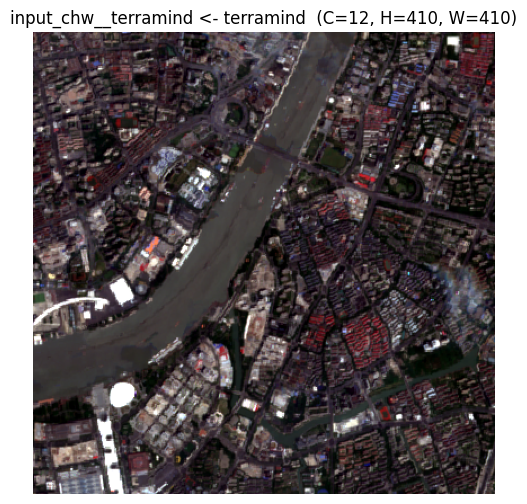

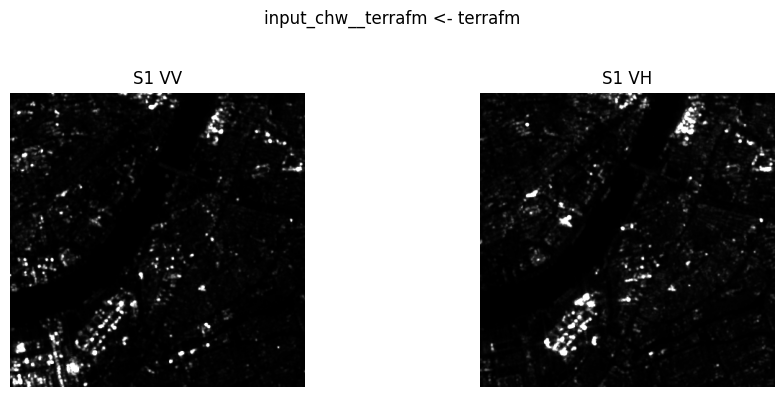


=== Visualizing saved grid embeddings ===


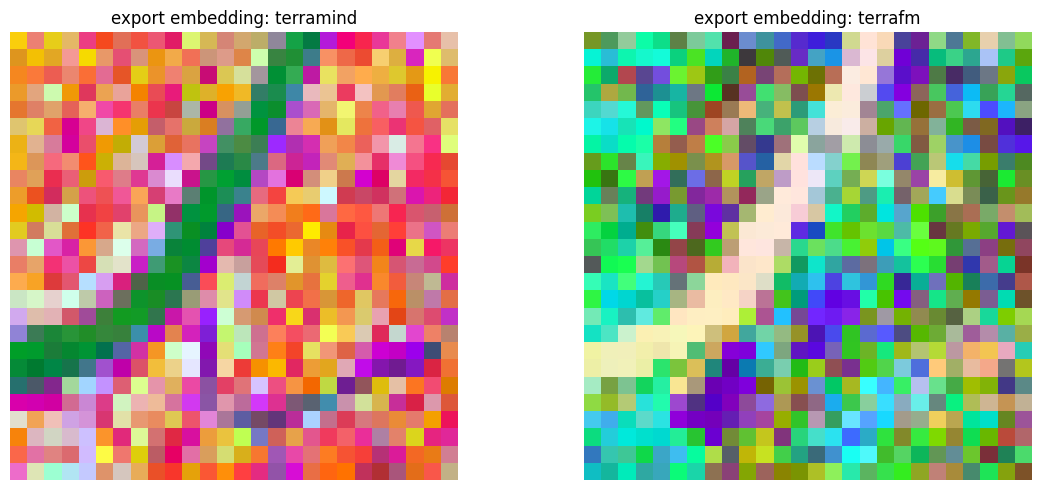

In [13]:
manifest, z = inspect_export_npz("exports/p1.npz")
pca = visualize_manifest_embeddings(manifest, z)